# Control estadístico de procesos con shewhart
(Anomaly Detection básico basado en TLC)

## Objetivo

Notebook autónomo para Google Colab con seis ejercicios: cartas p, np, c, u, I-MR y X̄-R. Cada caso incluye contexto, selección de carta, código explicado, gráfico, señales, interpretación profunda y conclusión.

Los datos son sintéticos, reproducibles y deliberadamente contienen patrones útiles para practicar. En un proyecto real, la Fase I debe usar datos históricos representativos y la Fase II debe evaluar datos nuevos contra límites congelados.

## Fuente y método

Se utiliza shewhart versión 0.1.1, instalada desde PyPI: https://pypi.org/project/shewhart/. La documentación oficial describe las funciones p_chart, np_chart, c_chart, u_chart, imr y xbar_r, además de los objetos Result con stats, table, signals, summary() y plot().

Principios: p y np modelan unidades defectuosas con distribución binomial; c y u modelan conteos de defectos con distribución Poisson; I-MR usa rangos móviles; X̄-R usa rangos promedio de subgrupos pequeños. Los límites de control describen variación histórica, no especificaciones del cliente.

### Supuestos

- Las observaciones están ordenadas en el tiempo.
- Cada lote o subgrupo es comparable.
- p/np: una unidad es defectuosa o no defectuosa.
- c/u: una unidad puede contener varios defectos.
- Una señal requiere investigación de causa especial; no justifica borrar el dato ni recalcular límites de inmediato.

In [1]:
%pip -q install shewhart==0.1.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 1.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shewhart as sw

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

print("shewhart importada correctamente")
print("Versión:", getattr(sw, "__version__", "0.1.1"))

shewhart importada correctamente
Versión: 0.1.1


In [3]:
def mostrar_resultado(resultado, nombre):
    print(resultado.summary())
    print("\nEstadísticas:")
    print(resultado.stats)
    print("\nNúmero de señales:", len(resultado.signals))
    for señal in resultado.signals:
        print(" -", señal)
    print("\nTabla calculada:")
    display(resultado.table.head(8))
    resultado.plot()
    plt.show()
    estado = "BAJO CONTROL" if resultado.ok else "FUERA DE CONTROL"
    print(f"\nLectura {nombre}: {estado}.")
    if resultado.ok:
        print("No hubo señales con las reglas elegidas. Esto respalda estabilidad estadística en el periodo observado, pero no demuestra capacidad ni cumplimiento de especificaciones.")
    else:
        print("Las señales deben relacionarse con lote, turno, equipo, operador, materia prima, calibración o método antes de tomar acción.")
    print("Recordatorio: los límites de control no son límites de aceptación del cliente.")

# 1. Carta p — proporción de unidades defectuosas

### Contexto

Una línea de ensamble inspecciona lotes de tamaño variable. Se registra cuántas unidades son defectuosas y se desea saber si la proporción se mantiene estable.

### Selección

Corresponde p porque cada unidad es defectuosa/no defectuosa y el tamaño inspeccionado cambia. Los límites se ajustan a cada denominador: lotes pequeños tienen más incertidumbre y límites más amplios.

### Datos y preparación

Este bloque crea un conjunto pequeño y reproducible. Cada variable tiene un nombre explícito para que el denominador, el conteo o la medición puedan auditarse.

In [4]:
tamano_lote = np.array([100,120,80,150,110,90,130,100,140,95,125,105,115,135,100,120,90,150,110,130])
defectuosos = np.array([5,7,3,8,6,4,7,5,9,4,6,5,6,7,5,6,4,8,6,7])
datos_p = pd.DataFrame({"lote": range(1,21), "defectuosos": defectuosos, "inspeccionados": tamano_lote})
datos_p["proporcion"] = datos_p["defectuosos"] / datos_p["inspeccionados"]
display(datos_p.head())

,lote,defectuosos,inspeccionados,proporcion
0,1,5,100,0.050000
1,2,7,120,0.058333
2,3,3,80,0.037500
3,4,8,150,0.053333
4,5,6,110,0.054545


### Cálculo, gráfico y lectura

La función de shewhart recibe el DataFrame y los nombres de las columnas mediante argumentos con palabra clave. rules añade reglas de Western Electric o Nelson para detectar patrones, y plot() dibuja la carta con sus límites.

shewhart p_chart - n=20 - rules=nelson - fitted (Phase I) - v0.1.1
  p_center=0.05142
verdict: IN CONTROL - no rule violations.

Estadísticas:
{'p_center': 0.0514161220043573}

Número de señales: 0

Tabla calculada:


,defectives,size,proportion,lcl,ucl,signal
0,5.0,100.0,0.050000,0.0,0.117670,False
1,7.0,120.0,0.058333,0.0,0.111897,False
2,3.0,80.0,0.037500,0.0,0.125490,False
3,8.0,150.0,0.053333,0.0,0.105512,False
4,6.0,110.0,0.054545,0.0,0.114586,False
5,4.0,90.0,0.044444,0.0,0.121253,False
6,7.0,130.0,0.053846,0.0,0.109524,False
7,5.0,100.0,0.050000,0.0,0.117670,False


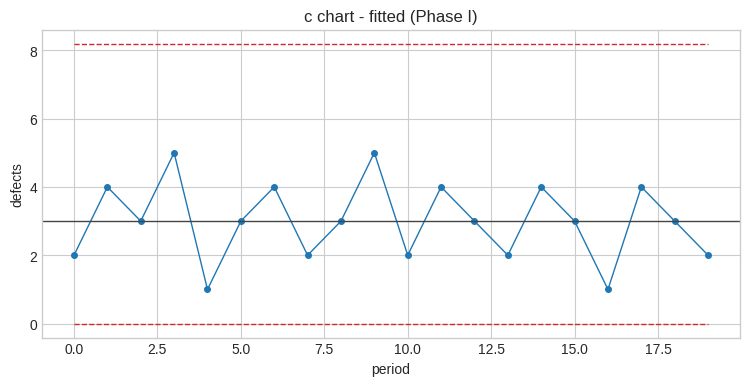


Lectura c: BAJO CONTROL.
No hubo señales con las reglas elegidas. Esto respalda estabilidad estadística en el periodo observado, pero no demuestra capacidad ni cumplimiento de especificaciones.
Recordatorio: los límites de control no son límites de aceptación del cliente.


In [5]:
carta_c = sw.c_chart(datos_c, defects="rayaduras", rules="nelson")
mostrar_resultado(carta_c, "c")

### Interpretación y conclusión

El centro expresa rayaduras promedio por pieza. Si aumenta el área inspeccionada, el conteo puede crecer sin que cambie la tasa; eso invalidaría la comparación. La estabilidad indica consistencia del mecanismo, no ausencia de defectos. Para mejorar, conviene estratificar por tipo de rayadura y complementar con Pareto.

**Conclusión:** mantener constante la oportunidad; usar u cuando cambie.

# 4. Carta u — defectos por unidad con oportunidad variable

### Contexto

Un centro de soporte audita un número distinto de páginas cada semana y cuenta errores de captura. Se necesita comparar calidad sin confundir volumen auditado con tasa de error.

### Selección

Corresponde u porque el denominador cambia y una página puede tener varios errores. La tasa de defectos por oportunidad es la medida comparable.

### Datos y preparación

Este bloque crea un conjunto pequeño y reproducible. Cada variable tiene un nombre explícito para que el denominador, el conteo o la medición puedan auditarse.

In [10]:
paginas = np.array([200,240,180,300,220,260,190,280,210,250,230,270,200,310,220,240,180,290,210,260])
errores = np.array([8,10,7,12,9,11,8,12,8,10,9,11,8,14,9,10,7,12,8,11])
datos_u = pd.DataFrame({"semana": range(1,21), "defectos": errores, "paginas": paginas})
datos_u["defectos_por_pagina"] = datos_u["defectos"] / datos_u["paginas"]
display(datos_u.head())

,semana,defectos,paginas,defectos_por_pagina
0,1,8,200,0.040000
1,2,10,240,0.041667
2,3,7,180,0.038889
3,4,12,300,0.040000
4,5,9,220,0.040909


### Cálculo, gráfico y lectura

La función de shewhart recibe el DataFrame y los nombres de las columnas mediante argumentos con palabra clave. rules añade reglas de Western Electric o Nelson para detectar patrones, y plot() dibuja la carta con sus límites.

shewhart u_chart - n=20 - rules=nelson - fitted (Phase I) - v0.1.1
  u_center=0.04093
verdict: OUT OF CONTROL - 1 signal(s):
  - nelson_4 (attr): points 4-19 - 14 in a row alternating up and down

Estadísticas:
{'u_center': 0.04092827004219409}

Número de señales: 1
 - nelson_4 (attr): points 4-19 - 14 in a row alternating up and down

Tabla calculada:


,defects,size,per_unit,lcl,ucl,signal
0,8.0,200.0,0.040000,0.000000,0.083844,False
1,10.0,240.0,0.041667,0.001752,0.080105,False
2,7.0,180.0,0.038889,0.000000,0.086166,False
3,12.0,300.0,0.040000,0.005888,0.075969,False
4,9.0,220.0,0.040909,0.000010,0.081847,True
5,11.0,260.0,0.042308,0.003289,0.078568,True
6,8.0,190.0,0.042105,0.000000,0.084959,True
7,12.0,280.0,0.042857,0.004658,0.077199,True


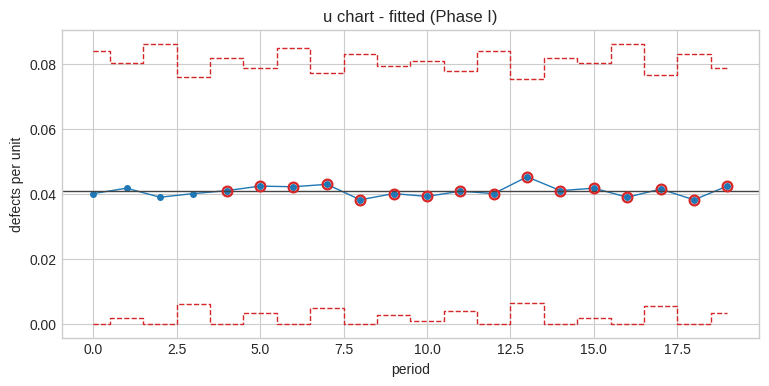


Lectura u: FUERA DE CONTROL.
Las señales deben relacionarse con lote, turno, equipo, operador, materia prima, calibración o método antes de tomar acción.
Recordatorio: los límites de control no son límites de aceptación del cliente.


In [11]:
carta_u = sw.u_chart(datos_u, defects="defectos", size="paginas", rules="nelson")
mostrar_resultado(carta_u, "u")

### Interpretación y conclusión

La carta u evita comparar conteos brutos con denominadores distintos. Un aumento de errores puede ser normal cuando se auditan muchas páginas. También hay que revisar mezcla de expedientes y cambios en el criterio de auditoría. Si ciertos tipos son más difíciles, puede ser mejor estratificar.

**Conclusión:** conservar el denominador visible; si la oportunidad ya no representa el riesgo, rediseñar la unidad.

# 5. Carta I-MR — datos individuales

### Contexto

Una dosificadora produce un peso una vez por hora. Solo hay una observación por periodo; se quiere detectar cambios de nivel y saltos entre horas.

### Selección

I monitorea cada medición y MR monitorea la diferencia entre observaciones consecutivas. La variación de corto plazo evita que una deriva histórica infle artificialmente los límites.

### Datos y preparación

Este bloque crea un conjunto pequeño y reproducible. Cada variable tiene un nombre explícito para que el denominador, el conteo o la medición puedan auditarse.

In [12]:
peso = np.array([500.1,499.8,500.2,500.0,500.3,499.9,500.1,500.2,500.0,500.4,500.2,500.1,500.3,500.0,500.2,500.1,500.4,500.3,500.5,500.4,500.6,500.5,500.7,500.6])
datos_imr = pd.DataFrame({"hora": range(1,len(peso)+1), "peso_g": peso})
display(datos_imr.head())

,hora,peso_g
0,1,500.1
1,2,499.8
2,3,500.2
3,4,500.0
4,5,500.3


### Cálculo, gráfico y lectura

La función de shewhart recibe el DataFrame y los nombres de las columnas mediante argumentos con palabra clave. rules añade reglas de Western Electric o Nelson para detectar patrones, y plot() dibuja la carta con sus límites.

shewhart imr - n=24 - rules=nelson - fitted (Phase I) - v0.1.1
  i_center=500.2  i_lcl=499.7  i_ucl=500.8  mr_center=0.213  mr_lcl=0  mr_ucl=0.6959  sigma_within=0.1888
verdict: OUT OF CONTROL - 2 signal(s):
  - nelson_4 (i): points 10-23 - 14 in a row alternating up and down
  - nelson_6 (i): points 18-23 - 4 of 5 beyond 1 sigma, same side

Estadísticas:
{'i_center': 500.24583333333334, 'i_lcl': 499.67941873315266, 'i_ucl': 500.812247933514, 'mr_center': 0.21304347826086364, 'mr_lcl': 0.0, 'mr_ucl': 0.6959133219354051, 'sigma_within': 0.1888048667268867}

Número de señales: 2
 - nelson_4 (i): points 10-23 - 14 in a row alternating up and down
 - nelson_6 (i): points 18-23 - 4 of 5 beyond 1 sigma, same side

Tabla calculada:


,value,moving_range,i_signal,mr_signal
0,500.1,NaN,False,False
1,499.8,0.3,False,False
2,500.2,0.4,False,False
3,500.0,0.2,False,False
4,500.3,0.3,False,False
5,499.9,0.4,False,False
6,500.1,0.2,False,False
7,500.2,0.1,False,False


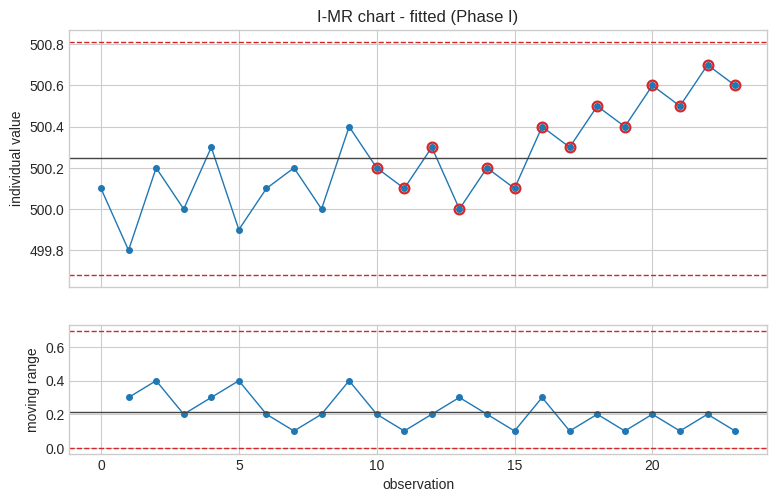


Lectura I-MR: FUERA DE CONTROL.
Las señales deben relacionarse con lote, turno, equipo, operador, materia prima, calibración o método antes de tomar acción.
Recordatorio: los límites de control no son límites de aceptación del cliente.


In [13]:
carta_imr = sw.imr(datos_imr, value="peso_g", rules="nelson")
mostrar_resultado(carta_imr, "I-MR")

### Interpretación y conclusión

I responde si el nivel instantáneo es compatible con la historia; MR responde si el salto entre horas es inusualmente grande. Una racha ascendente puede indicar desgaste, calentamiento o ajuste gradual. No deben eliminarse puntos señalados antes de investigar.

**Conclusión:** separar eventos puntuales observados en MR de cambios sostenidos observados en I; después de corregir, recalcular solo con una base homogénea.

# 6. Carta X̄-R — medias y rangos

### Contexto

Cada hora se toman cinco piezas consecutivas de una línea de corte. Se desea saber si cambia el promedio horario y si cambia la dispersión dentro de la hora.

### Selección

X̄-R corresponde a subgrupos racionales pequeños de tamaño constante. X̄ vigila el centro y R la variación interna. Conceptualmente se revisa primero R, porque la estabilidad de la dispersión sostiene la interpretación de X̄.

### Datos y preparación

Este bloque crea un conjunto pequeño y reproducible. Cada variable tiene un nombre explícito para que el denominador, el conteo o la medición puedan auditarse.

In [14]:
medias = [50.02,49.98,50.01,50.00,50.03,49.99,50.02,50.01,50.00,50.02,50.01,50.00,50.03,50.02,50.01,50.04,50.03,50.05,50.04,50.06]
amplitudes = [0.03,0.04,0.02,0.03,0.04,0.03,0.03,0.02,0.03,0.04,0.03,0.03,0.04,0.03,0.03,0.04,0.04,0.05,0.04,0.04]
filas = []
for hora,(media,amplitud) in enumerate(zip(medias,amplitudes),1):
    valores = media + np.array([-amplitud,-amplitud/2,0,amplitud/2,amplitud])
    for pieza,valor in enumerate(valores,1):
        filas.append({"hora": hora, "pieza": pieza, "diametro_mm": valor})
datos_xr = pd.DataFrame(filas)
display(datos_xr.head(10))

,hora,pieza,diametro_mm
0,1,1,49.990
1,1,2,50.005
2,1,3,50.020
3,1,4,50.035
4,1,5,50.050
5,2,1,49.940
6,2,2,49.960
7,2,3,49.980
8,2,4,50.000
9,2,5,50.020


### Cálculo, gráfico y lectura

La función de shewhart recibe el DataFrame y los nombres de las columnas mediante argumentos con palabra clave. rules añade reglas de Western Electric o Nelson para detectar patrones, y plot() dibuja la carta con sus límites.

shewhart xbar_r - n=20 - rules=western_electric - fitted (Phase I) - v0.1.1
  xbar_center=50.02  xbar_lcl=49.98  xbar_ucl=50.06  r_center=0.068  r_lcl=0  r_ucl=0.1438  sigma_within=0.02924  n_sub=5
verdict: OUT OF CONTROL - 3 signal(s):
  - we_1 (xbar): point 19 - 1 point beyond 3 sigma
  - we_2 (xbar): points 17-19 - 2 of 3 beyond 2 sigma, same side
  - we_3 (xbar): points 15-19 - 4 of 5 beyond 1 sigma, same side

Estadísticas:
{'xbar_center': 50.018499999999996, 'xbar_lcl': 49.97927628528221, 'xbar_ucl': 50.05772371471778, 'r_center': 0.06800000000000068, 'r_lcl': 0.0, 'r_ucl': 0.14378594186651528, 'sigma_within': 0.029235630813009672, 'n_sub': 5}

Número de señales: 3
 - we_1 (xbar): point 19 - 1 point beyond 3 sigma
 - we_2 (xbar): points 17-19 - 2 of 3 beyond 2 sigma, same side
 - we_3 (xbar): points 15-19 - 4 of 5 beyond 1 sigma, same side

Tabla calculada:


,mean,range,mean_signal,range_signal
hora,,,,
1,50.02,0.06,False,False
2,49.98,0.08,False,False
3,50.01,0.04,False,False
4,50.00,0.06,False,False
5,50.03,0.08,False,False
6,49.99,0.06,False,False
7,50.02,0.06,False,False
8,50.01,0.04,False,False


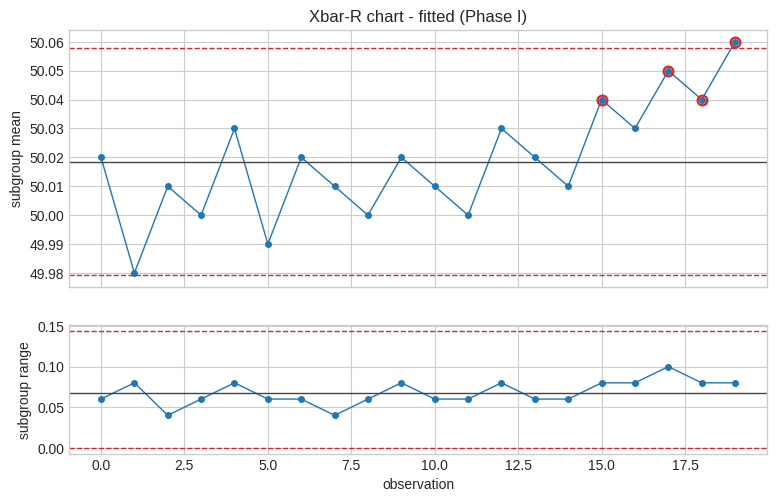


Lectura X̄-R: FUERA DE CONTROL.
Las señales deben relacionarse con lote, turno, equipo, operador, materia prima, calibración o método antes de tomar acción.
Recordatorio: los límites de control no son límites de aceptación del cliente.


In [15]:
carta_xr = sw.xbar_r(datos_xr, value="diametro_mm", subgroup="hora", rules="western_electric")
mostrar_resultado(carta_xr, "X̄-R")

### Interpretación y conclusión

X̄ fuera de control implica cambio del promedio: revisar centrado, ajuste o calibración. R fuera de control implica cambio de variabilidad: revisar herramienta, fijación o medición. Un proceso puede estar centrado pero ser inconsistente, o ser preciso pero estar desplazado.

**Conclusión:** validar primero R y luego X̄; para Fase II, congelar límites de Fase I y evaluar nuevos subgrupos.

# Comparación final y conclusiones

| Datos | Carta | Pregunta |
|---|---|---|
| Unidades defectuosas, tamaño variable | p | ¿Qué proporción es defectuosa? |
| Unidades defectuosas, tamaño constante | np | ¿Cuántas unidades son defectuosas? |
| Defectos, oportunidad constante | c | ¿Cuántos defectos ocurren por unidad fija? |
| Defectos, oportunidad variable | u | ¿Cuál es la tasa por oportunidad? |
| Una medición por periodo | I-MR | ¿Cambió el nivel o el salto? |
| Subgrupos pequeños constantes | X̄-R | ¿Cambió la media o la dispersión? |

## Conclusiones

1. La carta correcta depende del mecanismo de medición y del denominador.
2. Debe distinguirse unidad defectuosa de número de defectos.
3. Las señales orientan la investigación de causas especiales; no prueban la causa.
4. La estabilidad es previa a capacidad, desempeño o cumplimiento de metas.
5. En producción se debe documentar la Fase I, congelar límites para Fase II y conservar el historial de señales.

### Siguiente paso recomendado

Sustituir los datos sintéticos por datos reales con fecha, lote, turno, operador, equipo y denominador de oportunidad; ejecutar una Fase I depurada y comenzar el monitoreo de Fase II con límites congelados.